# 07 - Comparative Analysis

Baseline and improved models are plotted together on six research figures.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from core.production_model import ProductionUnit, STATE_NAMES
from core.network_model import InformationNetwork
from core.reliability_model import transmission_accuracy, rolling_failure_rate
from core.simulation_engine import SimulationEngine, SimulationConfig, summarize_by_time, performance_summary

OUTPUT_DIR = PROJECT_ROOT / 'outputs'
DATASET_DIR = OUTPUT_DIR / 'datasets'
GRAPH_DIR = OUTPUT_DIR / 'graphs'
LOG_DIR = OUTPUT_DIR / 'logs'
for directory in [DATASET_DIR, GRAPH_DIR, LOG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
base_path = DATASET_DIR / 'baseline_raw_runs.csv'
improved_path = DATASET_DIR / 'improved_dataset.csv'
if base_path.exists():
    baseline = pd.read_csv(base_path)
else:
    baseline = SimulationEngine(SimulationConfig()).run(steps=600, runs=150, mode='baseline', seed=2026)
    baseline.to_csv(base_path, index=False)
if improved_path.exists():
    improved = pd.read_csv(improved_path)
else:
    improved = SimulationEngine(SimulationConfig()).run(steps=600, runs=150, mode='improved', seed=2026)
    improved.to_csv(improved_path, index=False)

baseline_time = summarize_by_time(baseline)
improved_time = summarize_by_time(improved)
comparison = pd.concat([baseline.assign(model='Baseline'), improved.assign(model='Improved')], ignore_index=True)

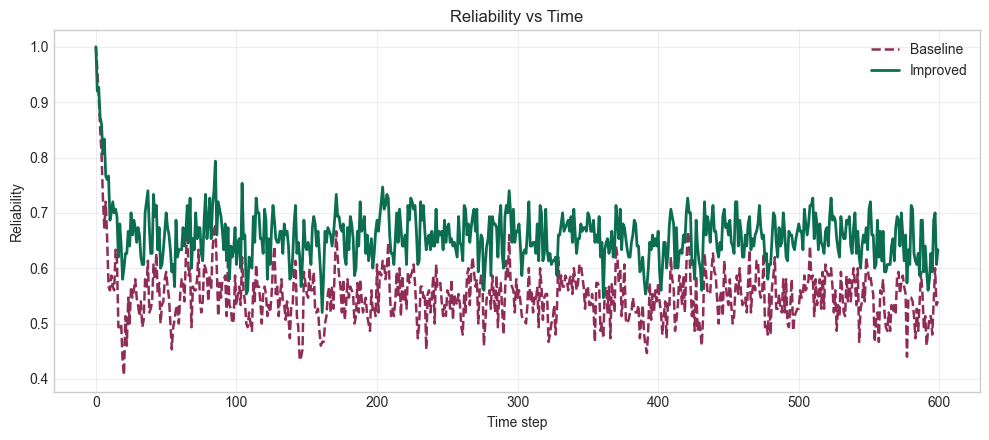

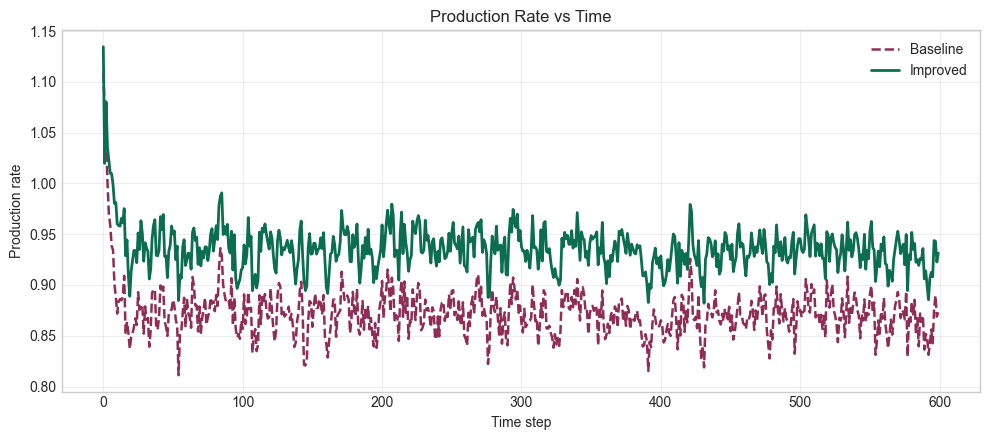

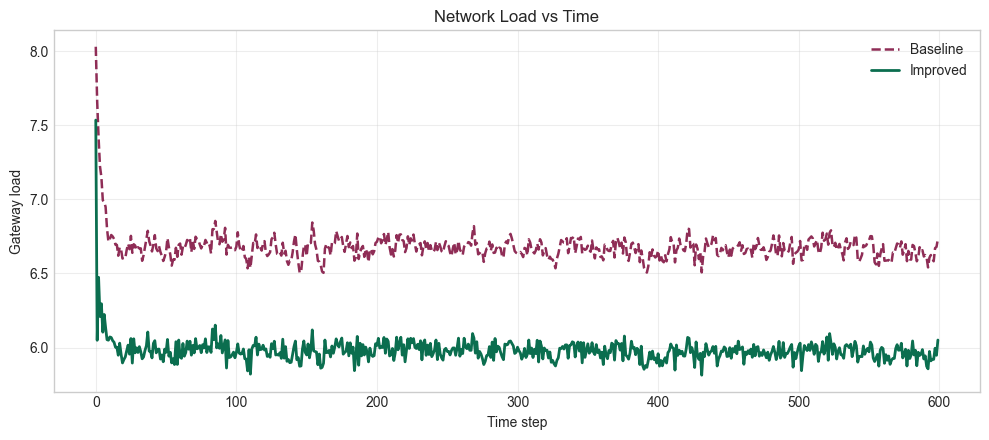

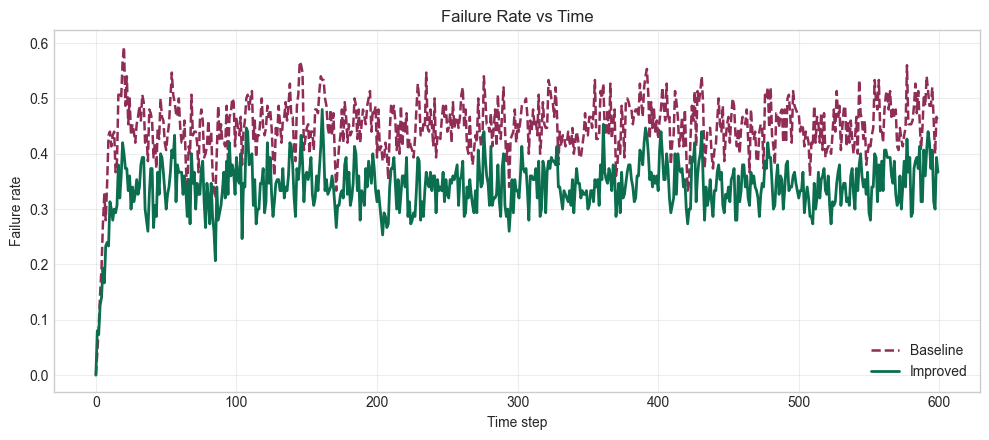

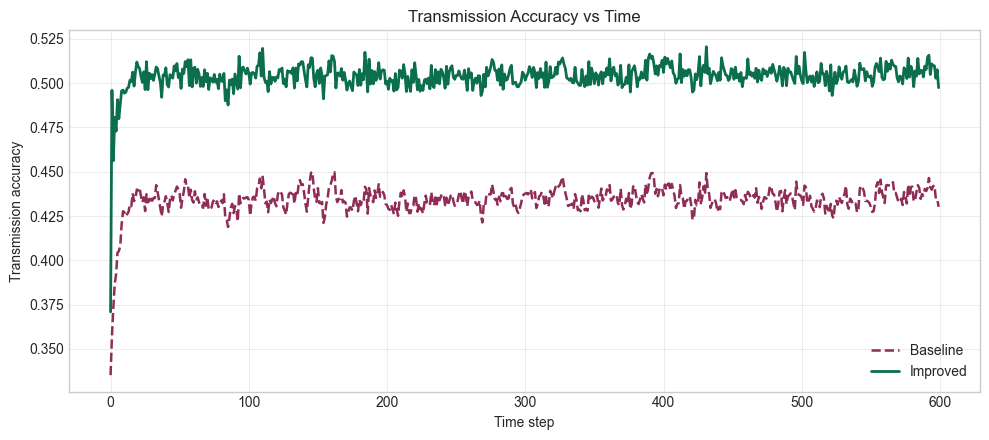

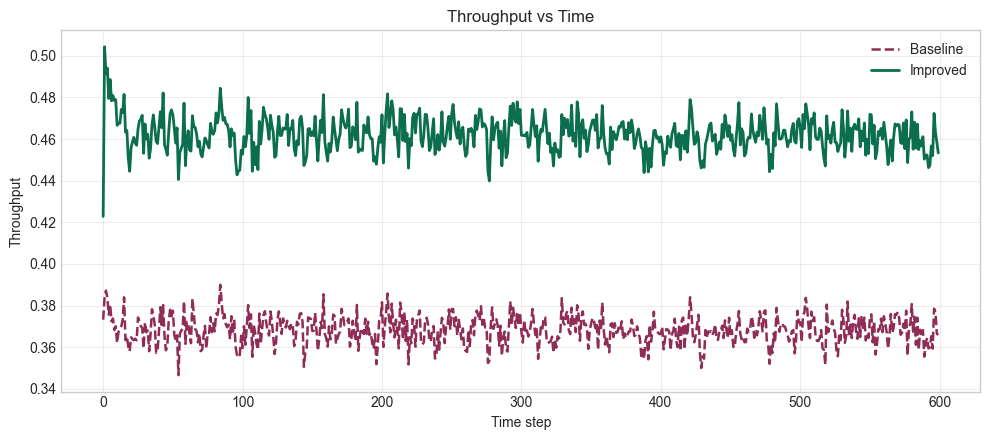

In [3]:
def plot_pair(y, ylabel, title, filename):
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.plot(baseline_time['time'], baseline_time[y], label='Baseline', color='#8f2d56', linestyle='--', linewidth=1.8)
    ax.plot(improved_time['time'], improved_time[y], label='Improved', color='#0b6e4f', linewidth=2.0)
    ax.set_title(title)
    ax.set_xlabel('Time step')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.35)
    fig.tight_layout()
    fig.savefig(GRAPH_DIR / filename, dpi=160)
    plt.show()

plot_pair('reliability', 'Reliability', 'Reliability vs Time', '07_01_reliability_vs_time.png')
plot_pair('production_rate', 'Production rate', 'Production Rate vs Time', '07_02_production_rate_vs_time.png')
plot_pair('gateway_load', 'Gateway load', 'Network Load vs Time', '07_03_network_load_vs_time.png')

baseline_time['failure_rate'] = 1.0 - baseline_time['reliability']
improved_time['failure_rate'] = 1.0 - improved_time['reliability']
plot_pair('failure_rate', 'Failure rate', 'Failure Rate vs Time', '07_04_failure_rate_vs_time.png')
plot_pair('transmission_accuracy', 'Transmission accuracy', 'Transmission Accuracy vs Time', '07_05_accuracy_vs_time.png')
plot_pair('throughput', 'Throughput', 'Throughput vs Time', '07_06_throughput_vs_time.png')

In [4]:
base_summary = performance_summary(baseline)
imp_summary = performance_summary(improved)
metrics = {
    'reliability_improvement_pct': 100 * (imp_summary['mean_reliability'] - base_summary['mean_reliability']) / base_summary['mean_reliability'],
    'failure_reduction_pct': 100 * (base_summary['failure_rate'] - imp_summary['failure_rate']) / base_summary['failure_rate'],
    'variance_reduction_pct': 100 * (base_summary['production_variance'] - imp_summary['production_variance']) / base_summary['production_variance'],
    'stability_improvement_pct': 100 * ((1 / imp_summary['production_variance']) - (1 / base_summary['production_variance'])) / (1 / base_summary['production_variance']),
    'accuracy_gain_pct': 100 * (imp_summary['mean_accuracy'] - base_summary['mean_accuracy']) / base_summary['mean_accuracy'],
    'throughput_gain_pct': 100 * (imp_summary['mean_throughput'] - base_summary['mean_throughput']) / base_summary['mean_throughput'],
}
summary_table = pd.DataFrame([base_summary, imp_summary], index=['Baseline', 'Improved'])
metrics_table = pd.Series(metrics, name='percent_change')
summary_table.to_csv(DATASET_DIR / 'comparative_summary.csv')
metrics_table.to_csv(DATASET_DIR / 'comparative_improvement_metrics.csv')
print(summary_table)
metrics_table

          mean_reliability  failure_rate  mean_production  \
Baseline          0.551422      0.448578         0.872585   
Improved          0.658478      0.341522         0.935973   

          production_variance  mean_accuracy  mean_load  mean_throughput  
Baseline             0.049240       0.434221   6.677571         0.368285  
Improved             0.046464       0.503953   5.980253         0.462159  


reliability_improvement_pct    19.414443
failure_reduction_pct          23.865550
variance_reduction_pct          5.637421
stability_improvement_pct       5.974212
accuracy_gain_pct              16.059100
throughput_gain_pct            25.489455
Name: percent_change, dtype: float64